In [17]:
import pandas as pd

data = pd.read_csv("ecommerce_sales_data.csv")

data.head()

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating,Total Sales
0,ORD0001,CUST9376,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3,1368.69
1,ORD0002,CUST3289,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5,3912.20
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4,3676.18
3,ORD0004,CUST8815,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5,9672.74
4,ORD0005,CUST1018,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3,14320.96


In [18]:
data.shape

(100, 13)

In [19]:
data.columns

Index(['Order ID', 'Customer ID', 'Gender', 'Age', 'Product Category',
       'Product Name', 'Quantity', 'Price', 'Order Date', 'Payment Method',
       'City', 'Rating', 'Total Sales'],
      dtype='str')

In [26]:
data.isnull().sum()

Order ID            0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product Name        0
Quantity            0
Price               0
Order Date          0
Payment Method      0
City                0
Rating              0
Total Sales         0
dtype: int64

In [21]:
data.duplicated().sum()

np.int64(0)

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          100 non-null    str    
 1   Customer ID       100 non-null    str    
 2   Gender            100 non-null    str    
 3   Age               100 non-null    int64  
 4   Product Category  100 non-null    str    
 5   Product Name      100 non-null    str    
 6   Quantity          100 non-null    int64  
 7   Price             100 non-null    float64
 8   Order Date        100 non-null    str    
 9   Payment Method    100 non-null    str    
 10  City              100 non-null    str    
 11  Rating            100 non-null    int64  
 12  Total Sales       100 non-null    float64
dtypes: float64(2), int64(3), str(8)
memory usage: 10.3 KB


In [24]:
data.describe()

,Age,Quantity,Price,Rating,Total Sales
count,100.000000,100.00000,100.000000,100.000000,100.000000
mean,37.720000,2.94000,2428.300600,3.000000,6942.198700
std,12.426007,1.44124,1508.115395,1.392621,5883.723034
min,18.000000,1.00000,118.330000,1.000000,295.100000
25%,28.000000,2.00000,1130.615000,2.000000,2494.127500
50%,37.500000,3.00000,2160.355000,3.000000,4901.680000
75%,49.000000,4.00000,3743.872500,4.000000,9472.980000
max,60.000000,5.00000,4836.370000,5.000000,23279.100000


In [27]:
data.select_dtypes(include="number").median()

Age              37.500
Quantity          3.000
Price          2160.355
Rating            3.000
Total Sales    4901.680
dtype: float64

In [28]:
data.select_dtypes(include="number").mode().iloc[0]

Age             23.00
Quantity         1.00
Price          118.33
Rating           3.00
Total Sales    295.10
Name: 0, dtype: float64

In [30]:
data["Order Date"] = pd.to_datetime(
    data["Order Date"],
    dayfirst=True
)

In [31]:
monthly_sales = data.groupby(
    data["Order Date"].dt.to_period("M")
)["Total Sales"].sum()

monthly_sales

Order Date
2024-07    17411.29
2024-08    94121.76
2024-09    90122.59
2024-10    26986.55
2024-11    58692.98
2024-12    44666.03
2025-01    51865.59
2025-02    39294.12
2025-03    37495.60
2025-04    77696.72
2025-05    48729.15
2025-06    81203.39
2025-07    25934.10
Freq: M, Name: Total Sales, dtype: float64

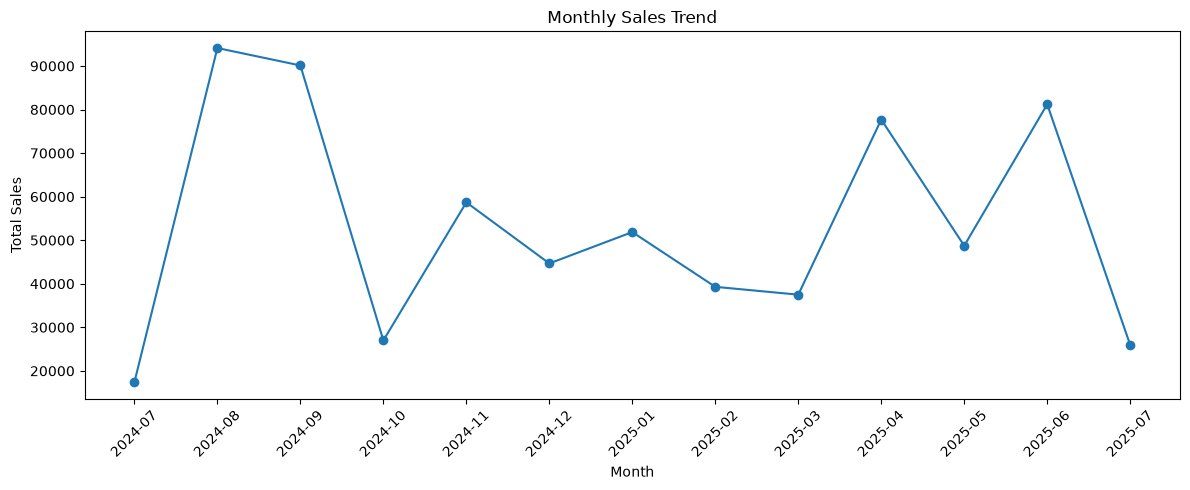

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation — Monthly Sales Trend

Monthly sales show noticeable fluctuations rather than a steady upward or downward trend. Sales peak around August–September 2024 and again during April–June 2025, while several months show substantially lower sales. This indicates that sales performance varies considerably over time and may reflect differences in customer demand across months.

In [33]:
quarterly_sales = data.groupby(
    data["Order Date"].dt.to_period("Q")
)["Total Sales"].sum()

quarterly_sales

Order Date
2024Q3    201655.64
2024Q4    130345.56
2025Q1    128655.31
2025Q2    207629.26
2025Q3     25934.10
Freq: Q-DEC, Name: Total Sales, dtype: float64

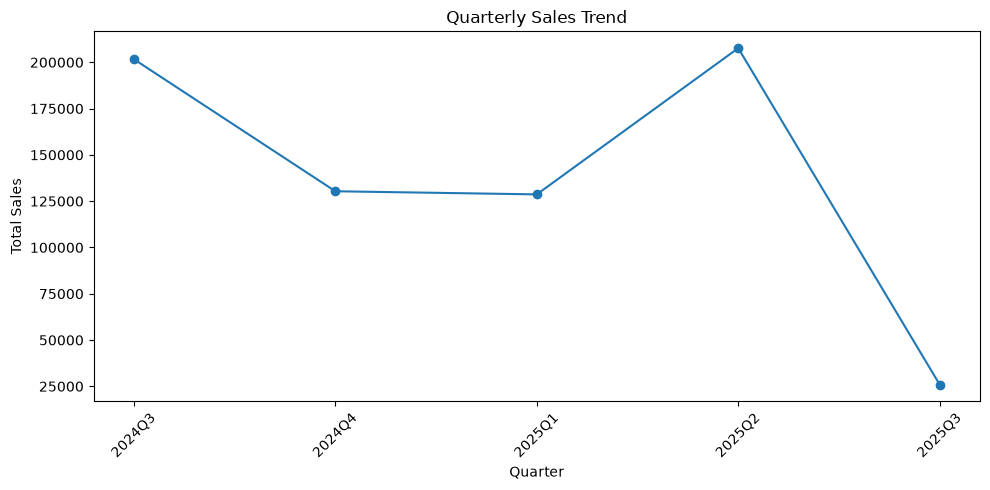

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation — Quarterly Sales Trend

Quarterly sales fluctuate considerably across the observed period. Sales were highest in Q3 2024 at approximately 201,655.64, followed by a decline in Q4 2024 and Q1 2025. Sales then increased substantially in Q2 2025 to approximately 207,629.26. Q3 2025 shows a sharp decline to approximately 25,934.10, making it the lowest-sales quarter in the dataset.

In [36]:
data["Age Group"] = pd.cut(
    data["Age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

age_group_counts = data["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
Under 18     3
18-25       19
26-35       23
36-45       24
46-55       21
56-65       10
65+          0
Name: count, dtype: int64

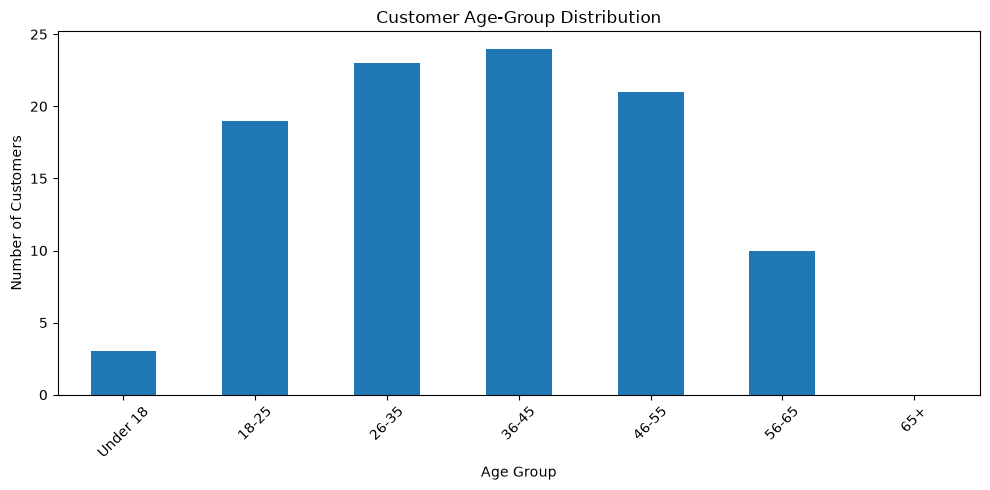

In [37]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind="bar")

plt.title("Customer Age-Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation — Customer Age-Group Distribution

The 36–45 age group has the highest number of customers with 24 customers, followed by the 26–35 group with 23 customers and the 46–55 group with 21 customers. Customers aged 56–65 account for 10 customers, while 18–25 accounts for 19 customers. Only 3 customers are under 18, and there are no customers aged 65 or above.

In [39]:
gender_counts = data["Gender"].value_counts()

gender_counts

Gender
Female    51
Male      49
Name: count, dtype: int64

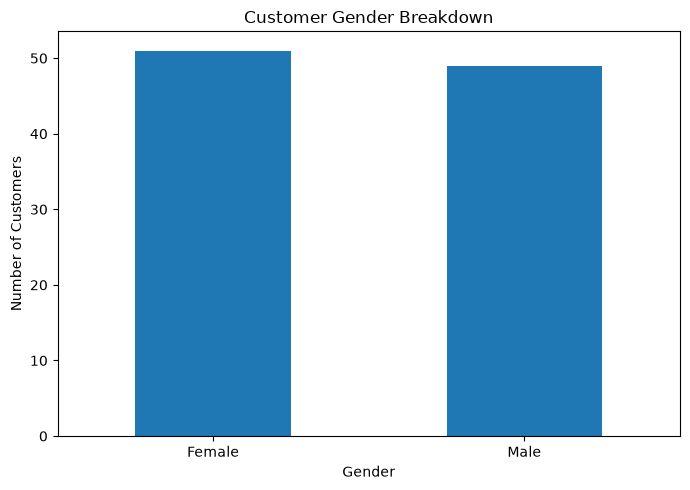

In [40]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation — Customer Gender Breakdown

The gender distribution is almost evenly balanced, with 51 female customers and 49 male customers. Female customers represent a slightly larger share of the dataset, but the difference is small.

In [41]:
top_10_products = (
    data.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products

Product Name
Smartphone    25
Curtains      25
Comics        23
Fiction       20
Smartwatch    19
T-Shirt       18
Perfume       17
Dress         16
Lego Set      16
Lamp          16
Name: Quantity, dtype: int64

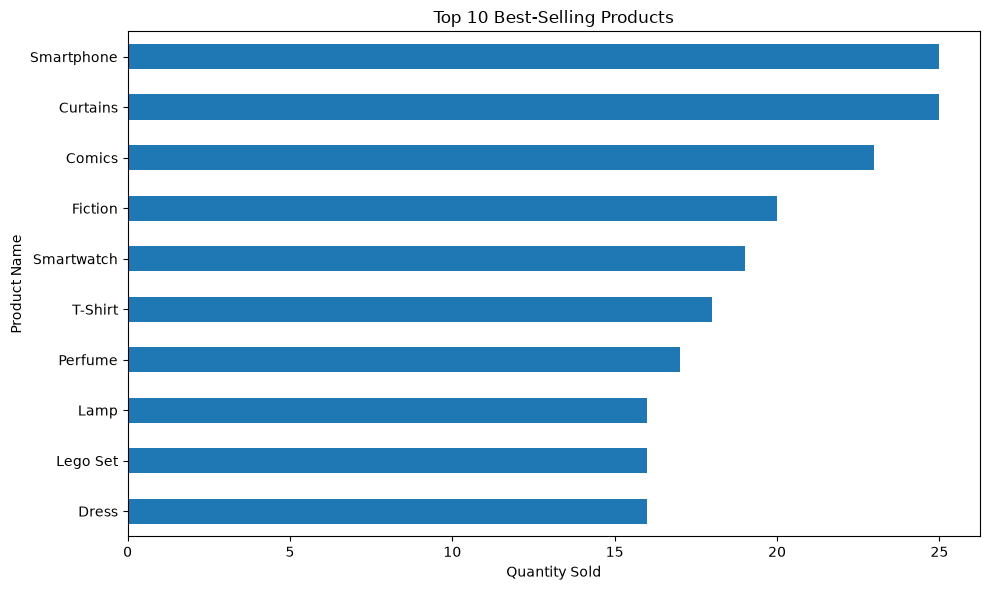

In [42]:
plt.figure(figsize=(10, 6))

top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### Observation — Top 10 Best-Selling Products

Smartphone and Curtains have the highest total quantity sold, with 25 units each. Comics follows with 23 units, while Fiction and Smartwatch recorded 20 and 19 units respectively. The remaining products in the top 10 sold between 16 and 18 units, showing relatively close sales volumes among the leading products.

In [43]:
category_sales = (
    data.groupby("Product Category")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product Category
Electronics    140811.26
Home           136365.47
Books          129177.30
Clothing       121504.99
Beauty          84457.92
Toys            81902.93
Name: Total Sales, dtype: float64

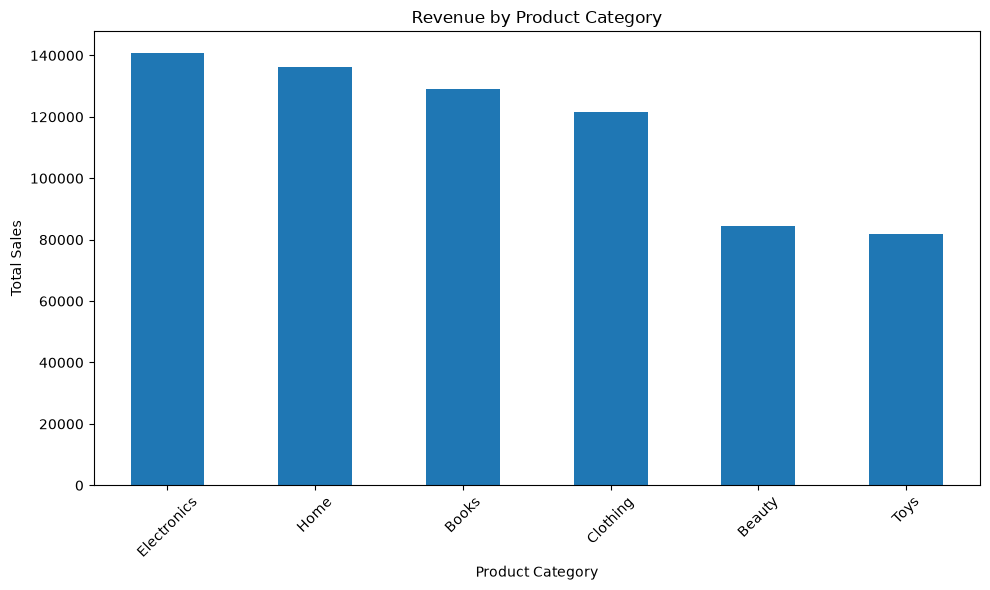

In [44]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation — Revenue by Product Category

Electronics generated the highest revenue at approximately 140,811.26, followed by Home at 136,365.47 and Books at 129,177.30. Clothing generated 121,504.99, while Beauty and Toys recorded lower revenues of 84,457.92 and 81,902.93 respectively. This shows that Electronics, Home, and Books are the major revenue-generating categories in the dataset.

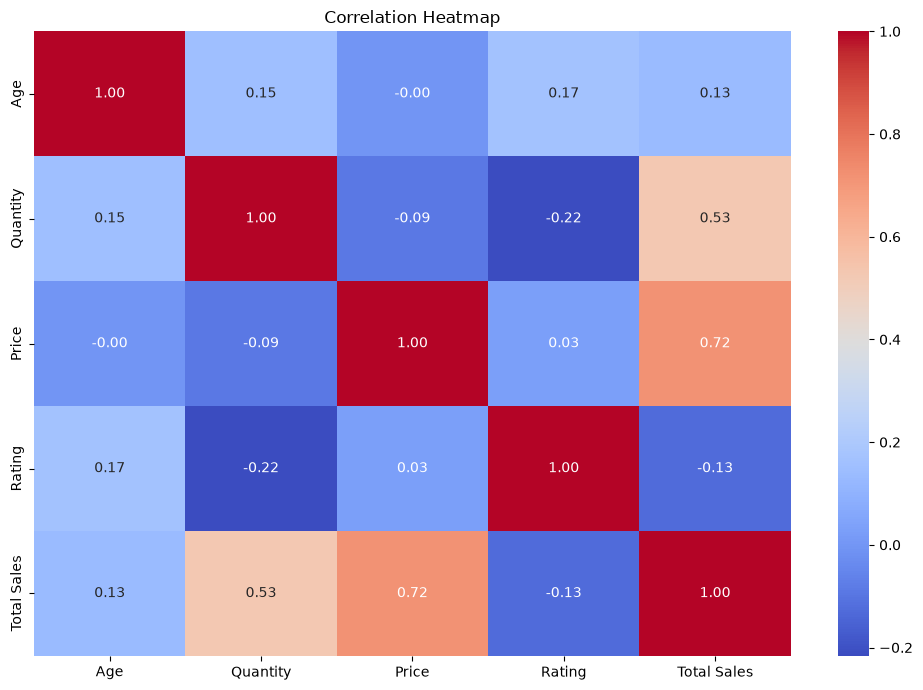

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include="number")

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

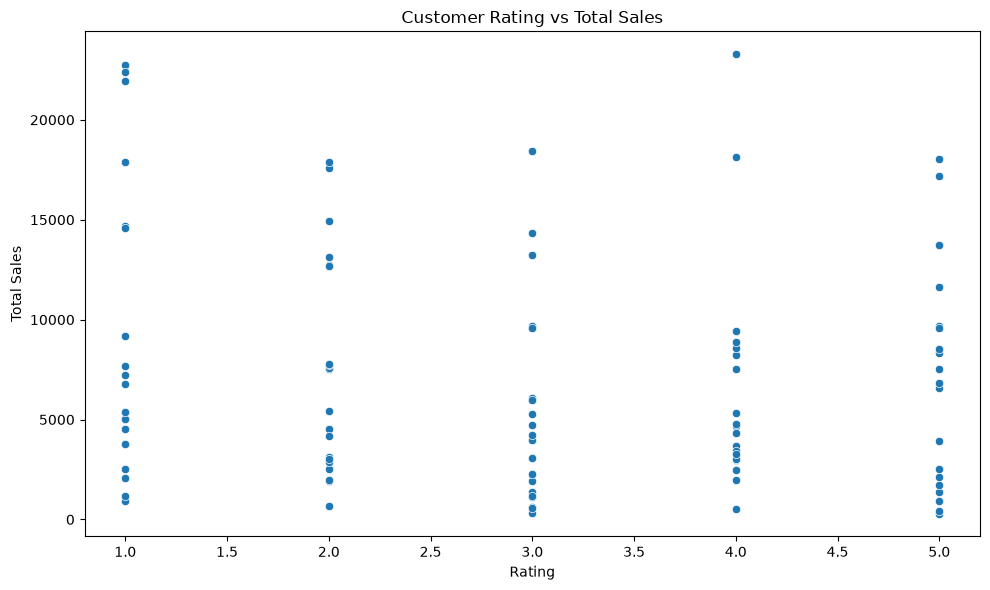

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Rating",
    y="Total Sales"
)

plt.title("Customer Rating vs Total Sales")
plt.xlabel("Rating")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation — Customer Rating vs Total Sales

The scatter plot shows that total sales vary considerably across different customer ratings. High sales values appear across multiple rating levels, indicating that a higher customer rating does not necessarily correspond to higher sales. This suggests that other factors, such as product category, price, and quantity purchased, may have a stronger influence on total sales.

## Conclusion

The analysis shows that e-commerce sales vary considerably across months and quarters, with Electronics generating the highest revenue among the product categories. The customer base is relatively balanced by gender, while customers aged 26–55 make up a large portion of the dataset. Smartphone and Curtains were the highest-selling products by quantity. The correlation analysis and rating-versus-sales visualization also indicate that sales are influenced by multiple factors rather than customer rating alone.

### Actionable Recommendations

1. **Focus on high-revenue categories:** Prioritize Electronics, Home, and Books through targeted promotions, product bundles, and inventory planning.

2. **Strengthen seasonal campaigns:** Use the observed monthly and quarterly sales fluctuations to plan promotions and inventory around periods of higher customer demand.

3. **Promote best-selling products:** Maintain sufficient stock of high-demand products such as Smartphones, Curtains, and Comics and consider cross-selling related products.

4. **Target key customer age groups:** Marketing campaigns can focus particularly on the 26–55 age groups, which represent a substantial portion of the customer dataset.

5. **Use multiple factors for sales strategy:** Customer ratings alone should not be used to predict sales. Product category, price, quantity, and customer purchasing behavior should also be considered.